In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = pd.read_csv('./data/train.csv')

In [3]:
X.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
X['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

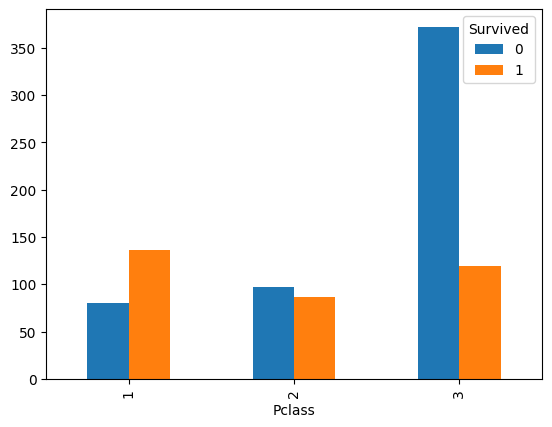

In [24]:
X.groupby('Pclass')['Survived'].value_counts().unstack().plot(kind='bar')

<Axes: xlabel='Sex'>

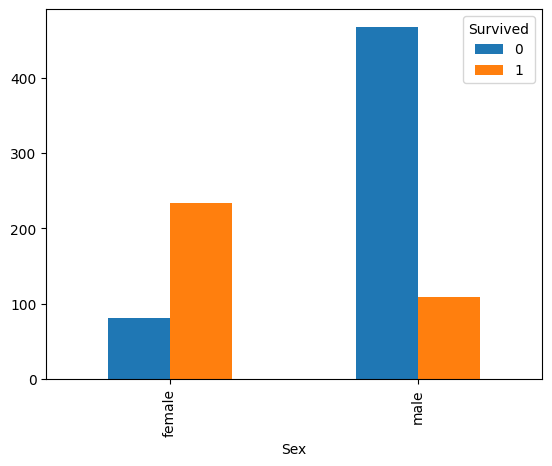

In [25]:
X.groupby('Sex')['Survived'].value_counts().unstack().plot(kind='bar')

<Axes: xlabel='Embarked'>

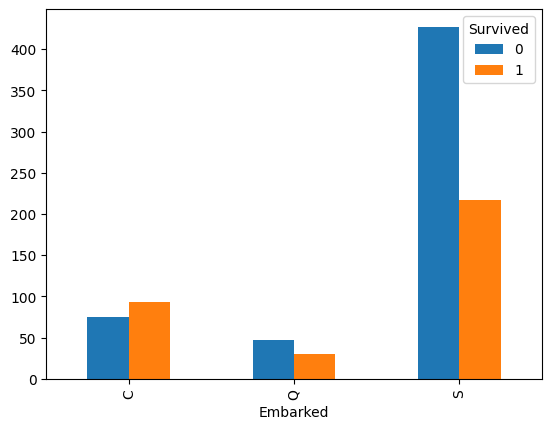

In [26]:
X.groupby('Embarked')['Survived'].value_counts().unstack().plot(kind='bar')

In [29]:
X['Name'][:20]

0                               Braund, Mr. Owen Harris
1     Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                Heikkinen, Miss. Laina
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                              Allen, Mr. William Henry
5                                      Moran, Mr. James
6                               McCarthy, Mr. Timothy J
7                        Palsson, Master. Gosta Leonard
8     Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                   Nasser, Mrs. Nicholas (Adele Achem)
10                      Sandstrom, Miss. Marguerite Rut
11                             Bonnell, Miss. Elizabeth
12                       Saundercock, Mr. William Henry
13                          Andersson, Mr. Anders Johan
14                 Vestrom, Miss. Hulda Amanda Adolfina
15                     Hewlett, Mrs. (Mary D Kingcome) 
16                                 Rice, Master. Eugene
17                         Williams, Mr. Charles

In [30]:
X['Title'] = X['Name'].str.extract('([A-Za-z]+)\.', expand=False)

In [ ]:
X['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

<Axes: xlabel='Title'>

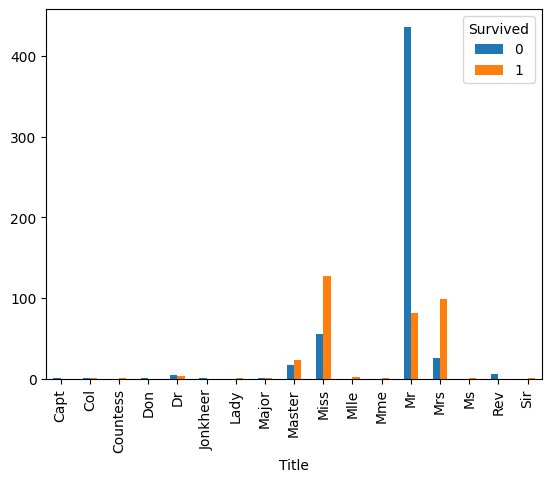

In [35]:
X.groupby('Title')['Survived'].value_counts().unstack().plot(kind='bar')

In [37]:
X['Title'] = X['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 'Sir', 'Lady', 'Jonkheer', 'Don', 'Dona', 'Mme', 'Ms', 'Mlle'], 'Other')

<Axes: xlabel='Title'>

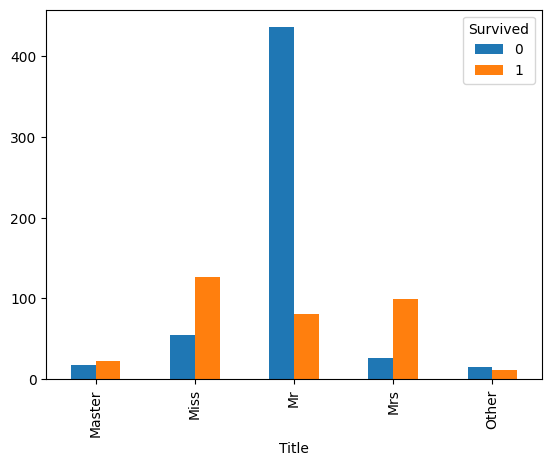

In [38]:
X.groupby('Title')['Survived'].value_counts().unstack().plot(kind='bar')

In [39]:
X.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs


In [40]:
X['Family'] = X['SibSp'] + X['Parch']
X['Family'].unique()

array([ 1,  0,  4,  2,  6,  5,  3,  7, 10])

<Axes: xlabel='Family'>

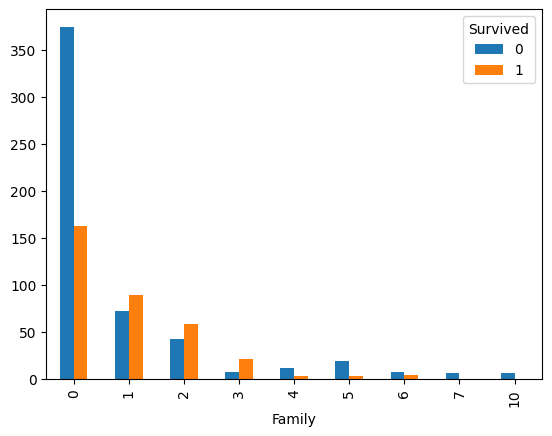

In [41]:
X.groupby('Family')['Survived'].value_counts().unstack().plot(kind='bar')

In [45]:
X['Is_Family'] = (X['Family'] > 0).astype(int)

In [46]:
X['Is_Family'].value_counts()

Is_Family
0    537
1    354
Name: count, dtype: int64

<Axes: xlabel='Is_Family'>

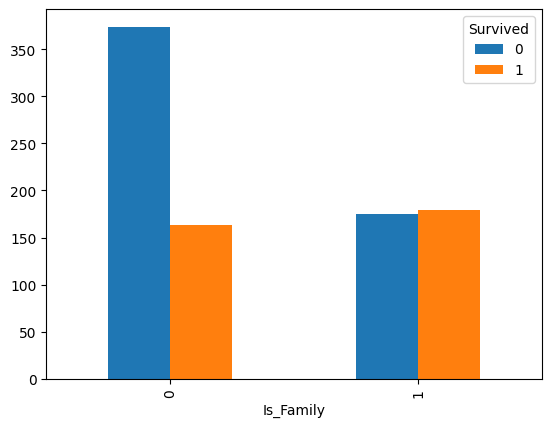

In [47]:
X.groupby('Is_Family')['Survived'].value_counts().unstack().plot(kind='bar')

In [48]:
X.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family,Is_Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,0


In [52]:
X['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [54]:
X['Cabin_Category'] = X['Cabin'].apply(lambda x: 'Unknown' if pd.isna(x) else x[0])

In [ ]:
X['Cabin_Category'].value_counts()

Cabin_Category
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

<Axes: xlabel='Cabin_Category'>

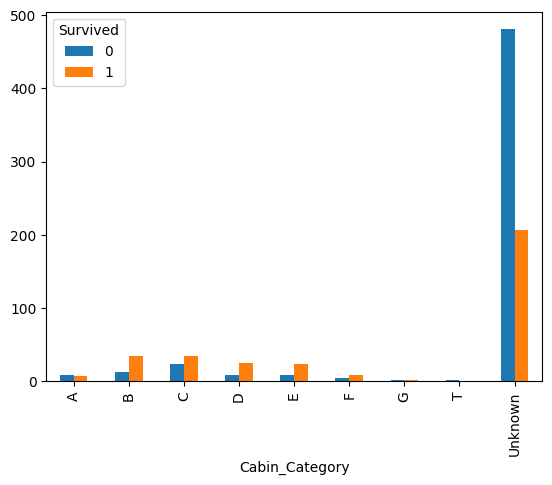

In [56]:
X.groupby('Cabin_Category')['Survived'].value_counts().unstack().plot(kind='bar')

In [57]:
X.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family,Is_Family,Cabin_Category
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,1,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,0,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,1,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,0,Unknown


In [59]:
X.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Family',
       'Is_Family', 'Cabin_Category'],
      dtype='str')

In [61]:
X = X[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'Is_Family', 'Cabin_Category']]

In [62]:
X.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Is_Family,Cabin_Category
0,0,3,male,22.0,7.2500,S,Mr,1,Unknown
1,1,1,female,38.0,71.2833,C,Mrs,1,C
2,1,3,female,26.0,7.9250,S,Miss,0,Unknown
3,1,1,female,35.0,53.1000,S,Mrs,1,C
4,0,3,male,35.0,8.0500,S,Mr,0,Unknown
